## Objetivo: a partir de los datos de ventas de libros proyectar las ventas del proximo mes

In [1]:
# Importo las librerias

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Cargo el dataset

df = pd.read_excel("Data/data.xlsx",  skiprows = 1,usecols = 'C:AU')

In [3]:
#Creo un vector de secuencia de fechas mensuales

import datetime

#Vector de meses
meses = pd.date_range('1/1/2018', periods = 37, freq ='MS').strftime("%Y-%m-%d").tolist()

#Nombre del resto de las columnas
columnas = ['TITLE','AUTHOR','LABEL','DIVISION','LAUCNCH DATE','SEGMENT','TYPE','PVP']

#Concateno las listas
labels = np.concatenate([columnas,meses])

#Renombro el data frame
df.columns = labels

df.head()


,TITLE,AUTHOR,LABEL,DIVISION,LAUCNCH DATE,SEGMENT,TYPE,PVP,2018-01-01,2018-02-01,...,2020-04-01,2020-05-01,2020-06-01,2020-07-01,2020-08-01,2020-09-01,2020-10-01,2020-11-01,2020-12-01,2021-01-01
0,Libro 1,Autor 1,GRJ-020,COMERCIAL,1999-01-01,AUTOAYUDA Y SUPERACIÓN,FONDO,259,17.0,9.0,...,18,19,73,194,107,121,101,106,241,120
1,Libro 2,Autor 2,AGL-021,COMERCIAL,2009-11-01,AUTOAYUDA,FONDO,239,13.0,18.0,...,5,0,11,12,13,16,14,8,30,11
2,Libro 3,Autor 3,ALF-022,LITERARIA,2010-09-01,BIBLIOTECA SARAMAGO,FONDO,329,133.0,122.0,...,31,9,31,88,50,71,87,61,111,33
3,Libro 4,Autor 4,DEB-023,BOLSILLO,2011-05-01,CONTEMPORÁNEA,FONDO,209,161.0,115.0,...,43,43,76,142,106,91,67,67,153,56
4,Libro 5,Autor 5,DEB-023,BOLSILLO,2011-05-01,CONTEMPORÁNEA,FONDO,209,68.0,86.0,...,34,73,71,99,82,77,64,69,125,71


In [4]:
#hago un melt con el data frame

df = df.melt(id_vars= columnas, var_name= "Fecha",value_name= "Cantidad")

df


,TITLE,AUTHOR,LABEL,DIVISION,LAUCNCH DATE,SEGMENT,TYPE,PVP,Fecha,Cantidad
0,Libro 1,Autor 1,GRJ-020,COMERCIAL,1999-01-01,AUTOAYUDA Y SUPERACIÓN,FONDO,259,2018-01-01,17.0
1,Libro 2,Autor 2,AGL-021,COMERCIAL,2009-11-01,AUTOAYUDA,FONDO,239,2018-01-01,13.0
2,Libro 3,Autor 3,ALF-022,LITERARIA,2010-09-01,BIBLIOTECA SARAMAGO,FONDO,329,2018-01-01,133.0
3,Libro 4,Autor 4,DEB-023,BOLSILLO,2011-05-01,CONTEMPORÁNEA,FONDO,209,2018-01-01,161.0
4,Libro 5,Autor 5,DEB-023,BOLSILLO,2011-05-01,CONTEMPORÁNEA,FONDO,209,2018-01-01,68.0
...,...,...,...,...,...,...,...,...,...,...
24267,Libro 653,Autor 653,ALFJ-025,INFANTIL Y JUVENIL,2018-12-01,FICCIÓN JUVENIL,FONDO,309,2021-01-01,2.0
24268,Libro 654,Autor 654,ALFI-031,INFANTIL Y JUVENIL,2018-12-01,MIDDLE GRADE,FONDO,199,2021-01-01,3.0
24269,Libro 655,Autor 655,LUM-030,LITERARIA,2018-12-01,LUMEN,FONDO,289,2021-01-01,48.0
24270,Libro 656,Autor 656,ROCI-028,INFANTIL Y JUVENIL,2018-12-01,JUVENIL,FONDO,249,2021-01-01,11.0


In [5]:
df['Fecha'] = pd.to_datetime(df['Fecha'])

df['Cantidad'] = df['Cantidad'].fillna(0)

df.isnull().sum()



TITLE           0
AUTHOR          0
LABEL           0
DIVISION        0
LAUCNCH DATE    0
SEGMENT         0
TYPE            0
PVP             0
Fecha           0
Cantidad        0
dtype: int64

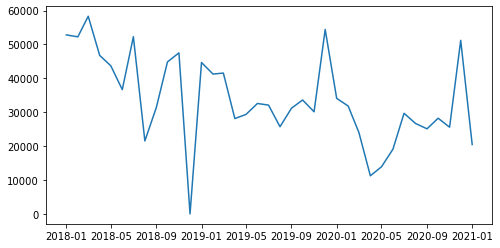

In [6]:
#Visalizamos la serie de tiempo en general


df_agrupado = df.groupby('Fecha', as_index=False).sum('Cantidad')


fig, ax = plt.subplots(figsize=(8,4))

plt.plot(df_agrupado["Fecha"], df_agrupado["Cantidad"])
plt.show()

In [7]:
#Agregamos la columa mes, quarter, year


df_agrupado['Mes'] = pd.DatetimeIndex(df_agrupado['Fecha']).month
df_agrupado['Anio'] = pd.DatetimeIndex(df_agrupado['Fecha']).year
df_agrupado['Trim'] = pd.DatetimeIndex(df_agrupado['Fecha']).quarter

df_agrupado= df_agrupado.sort_index()


<AxesSubplot:title={'center':'Cantidad'}, xlabel='Trim'>

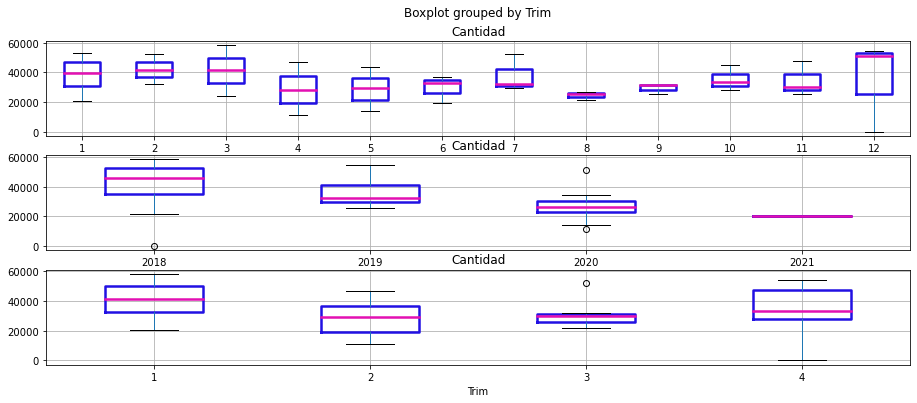

In [8]:
#Vemos estacionalidad con valores inferiores a enero 2021

fig1, ax = plt.subplots(3, figsize=(15, 6))

plt.suptitle('')
ax[0].set_xlabel("")
ax[1].set_xlabel("")
ax[2].set_xlabel("")

boxprops = dict(linestyle='-', linewidth=2.5, color='#2110e3')
medianprops = dict(linestyle='-', linewidth=2.5, color='#e310b2')

df_agrupado.query("Fecha < '2022-01-01'").boxplot(column=['Cantidad'], by= 'Mes', ax=ax[0],
                 showfliers=False, showmeans=False,boxprops=boxprops,medianprops=medianprops)

df_agrupado.query("Fecha < '2022-01-01'").boxplot(column=['Cantidad'], by= 'Anio', ax=ax[1],
                                                 boxprops=boxprops,medianprops=medianprops)

df_agrupado.query("Fecha < '2022-01-01'").boxplot(column=['Cantidad'], by= 'Trim', ax=ax[2],
                                                 boxprops=boxprops,medianprops=medianprops)


In [9]:
#Armo el dataset para el forecast

st_libros = df.groupby(["TITLE","Fecha"],as_index=False).sum("Cantidad")

#Imputo valor a diciembre 2018 con el promedio de 2019 y 2020

#Promedio libros diciembre 2019 y 2020

prom_libros = st_libros.query("Fecha == '2019-12-31' | Fecha == '2020-12-31'").groupby(["TITLE"]).mean('Cantidad').reset_index()

#Creo la variable fecha
prom_libros['Fecha'] = pd.to_datetime('2018-12-31')


#Agrego a st_libros sin 2018, el promedio de 2019 y 2020
st_libros = st_libros.query("Fecha != '2018-12-31'").append(prom_libros)

#Observo la tendencia



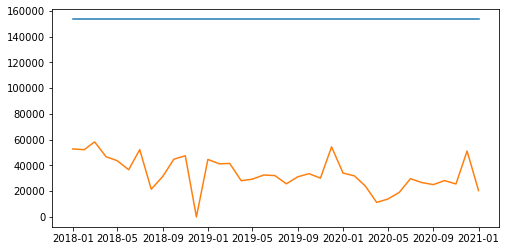

In [10]:
fig, ax = plt.subplots(figsize=(8,4))

plt.plot(st_libros.groupby(['Fecha']).sum('Cantidad'))
plt.show()

In [11]:
#Creamos los modelos de forecast: una regresion lineal simple y un random forest

#Importamos las librerias

from sklearn.ensemble import RandomForestRegressor
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from math import sqrt #Para obtener la raiz cuadrada
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ParameterGrid
from sklearn.inspection import permutation_importance
import multiprocessing

In [12]:
st_libros=st_libros.drop('PVP', axis=1)

st_libros['Time']= st_libros.groupby('TITLE').cumcount()

In [83]:
#Armo un dataframe con libro 1 para crear el modelo antes de escalarlo al resto

libro_1 = st_libros.query("TITLE == 'Libro 1'")
libro_2 = st_libros.query("TITLE == 'Libro 2'")

#Convierto la variable fecha en numérica


#Dividimos el dataset en train y test

X_train, X_test, y_train, y_test = train_test_split(
                                        libro_1.drop(['TITLE','Fecha','Cantidad'],axis=1),
                                        libro_1['Cantidad'],
                                        random_state = 123)



In [86]:
#Creamos el model

reg = linear_model.LinearRegression()

reg.fit(X_train,y_train)


LinearRegression()

In [87]:
#Realizamos las primeras predicciones sin tuning

predicciones = reg.predict(X_test)
predicciones

array([ 49.8981688 ,  55.96628151,  71.13656328,  65.06845057,
        46.86411244, 128.78363403, 101.47712683, 125.74957767,
        68.10250693,  86.30684506])

In [16]:
rmse = mean_squared_error(y_test, predicciones, squared=False)
rmse

15.301705436528175

In [17]:
#Agrego un indice "Time" que es una secuencia de numeros de 1 a n por TITLE (Libro)

st_libros['Time']= st_libros.groupby('TITLE').cumcount()


In [18]:
#Creo listas para guardar los datos de entrenamiento y de test

X_train_list = []
X_test_list = []
y_train_list = []
y_test_list = []

#Creo un indice con la cantidad de libros
libros = st_libros['TITLE'].unique()


#Armo el loop
for i in range(0,len(st_libros['TITLE'].unique())):
    X_train,X_test,y_train,y_test = train_test_split(
    st_libros[st_libros['TITLE'] == libros[i]].drop(['TITLE','Fecha','Cantidad'],axis=1),
    st_libros.loc[st_libros['TITLE'] == libros[i],"Cantidad"],
    random_state = 123)
    #Agrego los valores
    X_train_list.append(X_train)
    X_test_list.append(X_test)
    y_train_list.append(y_train)
    y_test_list.append(y_test)



[Tutorial piola](https://moez-62905.medium.com/multiple-time-series-forecasting-in-python-fab0a8a1afdb)

In [19]:
#Creamos el modelo
model = linear_model.LinearRegression()
model

LinearRegression()

In [102]:
# #Ajustamos el modelo

model = {}
model_fit = []

for i in range(0,len(st_libros['TITLE'].unique())):
    lm = linear_model.LinearRegression() #Importante generar una instancia del modelo en cada bucle
    model[i] = lm
    mf = model[i].fit(X_train_list[i],y_train_list[i])
    model_fit.append(mf)


In [106]:
#Realizamos las primeras predicciones sin tuning

predicciones_list = []

for i in range(0,len(st_libros['TITLE'].unique())):
    pred = model_fit[i].predict(X_test_list[i])
    predicciones_list.append(pred)

In [110]:
predicciones_list[201]

array([15.26213483, 16.6877717 , 20.25186386, 18.826227  , 14.5493164 ,
       33.7954141 , 27.3800482 , 33.08259567, 19.53904543, 23.81595603])

In [54]:
#Obtenemos las métricas de error

rmse_list = []

for i in range(0,len(st_libros['TITLE'].unique())):
    error = sqrt(mean_squared_error(y_test_list[i], predicciones_list[i], squared=False))
    rmse_list.append(error)
    



In [93]:
print(predicciones_list[1])
print(predicciones_list[2])

[1178.572595   1083.72355114  846.60094151  941.44998536 1225.99711692
  -54.46497511  372.35572223   -7.04045318  894.02546343  609.47833187]
[1178.572595   1083.72355114  846.60094151  941.44998536 1225.99711692
  -54.46497511  372.35572223   -7.04045318  894.02546343  609.47833187]
